open cv 라이브러리 설치/호출

# 특성추출 기법

In [1]:
pip install opencv-python

In [53]:
import os
import time
import copy
import glob
import cv2
import shutil

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.utils. data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

이미지 데이터 전처리 방법 정의

In [54]:
data_path = '/content/drive/MyDrive/Euron/catanddog/train'
#torchvision.transform은 이미지 데이터를 변환하여 모델의 입력으로 사용할 수 있게 해줌
transform = transforms.Compose(
    [
        transforms.Resize([256, 256]), #이미지 크기 조정
        transforms.RandomResizedCrop(224), #이미지를 랜덤한 크기 및 비율로 자름
        transforms.RandomHorizontalFlip(), #이미지를 랜덤하게 수평으로 뒤집음
        transforms.ToTensor() # 이미지 데이터를 텐서로 변환
    ]
)
#datasets.ImageFolder 데이터로더가 데이터를 불러온 대상과 방법 정의
train_dataset = torchvision.datasets.ImageFolder(
    data_path, #불러올 데이터가 위치한 경로
    transform=transform #이미지 데이터에 대한 전처리
)
#앞에서 정의한 ImageFolder를 데이터로더에 할당
train_loader= torch.utils.data.DataLoader(
    train_dataset, #데이터셋 지정
    batch_size=32, #데이터양 결정하는 배치 크기 설정
    shuffle=True, #데이터를 무작위로 섞을지 결정
    num_workers=8 #하위 프로세스 개수 결정
)

print(len(train_dataset))

385


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


학습에 사용될 이미지 출력

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


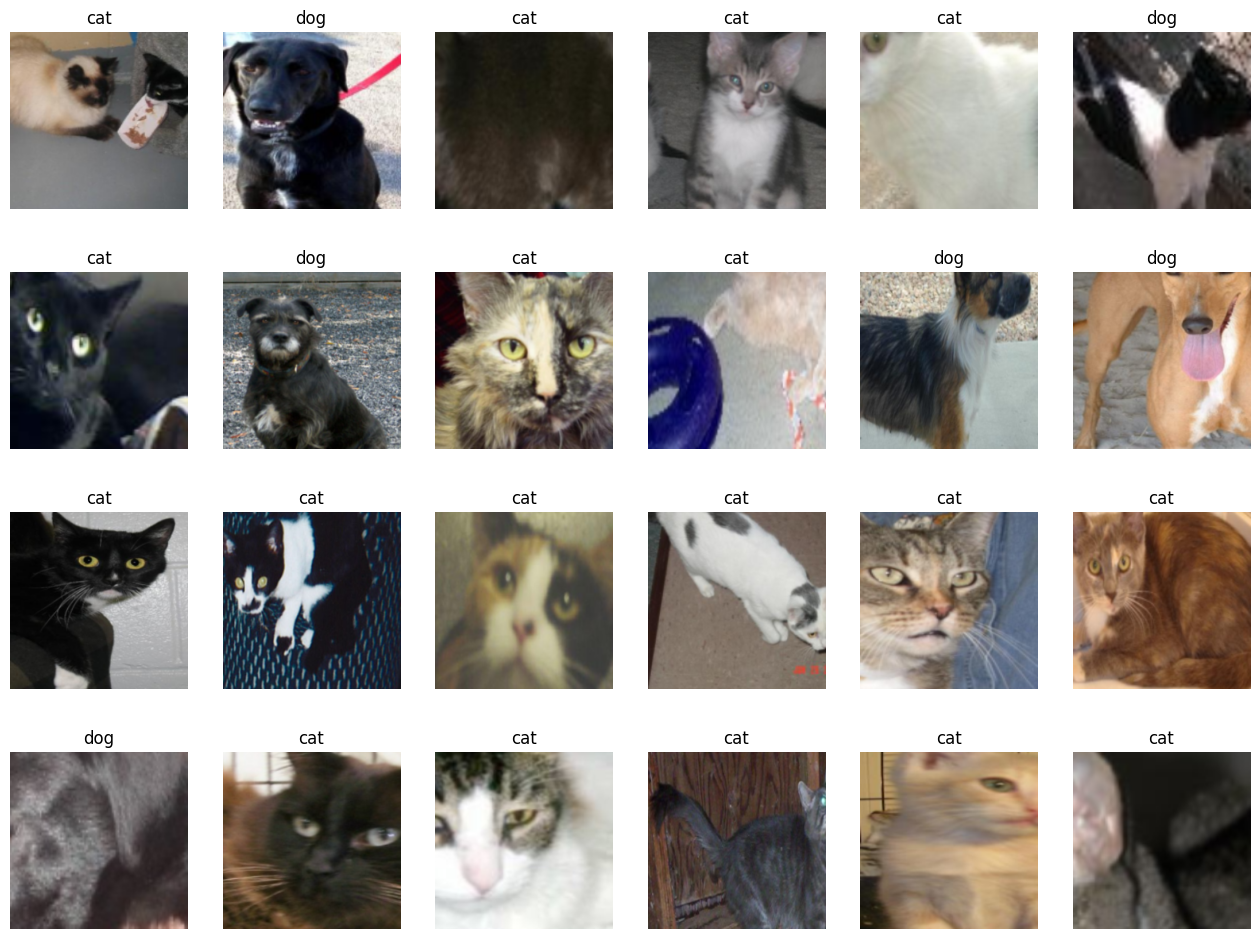

In [55]:
samples, labels = next(iter(train_loader)) #train_loader에서 데이터를 하나씩 꺼내옴
classes = {0:'cat', 1:'dog'}
fig = plt.figure(figsize=(16, 24))
for i in range(24):
  a = fig.add_subplot(4, 6, i+1)
  a.set_title(classes[labels[i].item()])
  a.axis('off')
  a.imshow(np.transpose(samples[i].numpy(), (1, 2, 0))) #행과 열을 바꿈으로써 행렬의 차원 변경
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

사전 훈련된 ResNet18모델 내려받기

In [56]:
resnet18 = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


사전 훈련된 모델의 파라미터 할습 유무 지정

In [57]:
def set_parameter_requires_grad(model, feature_extracting=True):
  if feature_extracting:
    for param in model.parameters():
      param.requires_grad = False #역전파 중 파라미터들에 대한 변화를 계산할 필요가 없음 의미, 모델의 일부(합성곱층과 풀링층)를 고정하고 나머지 학습

set_parameter_requires_grad(resnet18)

In [58]:
#resnet18에 완전 연결층 추가
resnet18.fc = nn.Linear(512, 2) #class=2개 의미

In [59]:
#모델의 파라미터 값 확인
for name, param in resnet18.named_parameters():
  if param.requires_grad:
    print(name, param.data)

fc.weight tensor([[-0.0156,  0.0118, -0.0153,  ..., -0.0139, -0.0205, -0.0333],
        [ 0.0188,  0.0146, -0.0159,  ...,  0.0141,  0.0316,  0.0051]])
fc.bias tensor([0.0375, 0.0386])


내려받은 ResNet18모델의 마지막에 완전연결층을 추가한 모델을 보여줌

In [60]:
#모델 객체 생성 및 손실 함수 정의
model = models.resnet18(pretrained=True) #모델의 객체 생성

for param in model.parameters(): #모델의 합성곱층 가중치 고정
  param.requires_grad = False

model.fc = torch.nn.Linear(512, 2)
for param in model.fc.parameters(): #완전연결층은 학습
  param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss() #손실함수 정의
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

모델 학습 함수 생성

In [61]:
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13, is_train=True):
  since = time.time()#컴퓨터의 현재 시간을 구하는 함수
  acc_history=[]
  loss_history=[]
  best_acc = 0.0

  for epoch in range(num_epochs): #에포크(13)만큼 반복
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    print('-'*10)

    running_loss=0.0
    running_corrects=0

    for inputs, labels in dataloaders: #데이터로더에 전달된 데이터만큼 반복
      inputs = inputs.to(device)
      labels = labels.to(device)

      model.to(device)
      optimizer.zero_grad() #기울기를 0으로 설정
      outputs = model(inputs) #순전파 학습
      _, preds = torch.max(outputs, 1)
      loss = criterion(outputs, labels)
      loss.backward() #역전파 학습
      optimizer.step()

      running_loss += loss.item() * inputs.size(0) #출력 결과와 레이블의 오차를 계산한 결과를 누적하여 저장
      running_corrects += torch.sum(preds == labels.data) #출력 결과와 레이블이 동일하지 확인할 결과를 누적하여 저장

    epoch_loss = running_loss / len(dataloaders.dataset) #평군 오차 계산
    epoch_acc = running_corrects.double() / len(dataloaders.dataset) #평균 정확도 계산

    print('Loss: {:.4f} Acc:{:.4f}'.format(epoch_loss, epoch_acc))

    if epoch_acc > best_acc:
        best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    loss_history.append(epoch_loss)
    torch.save(model.state_dict(), os.path.join('/content/drive/MyDrive/Euron/catanddog/',
               '{0:0=2d}.pth'.format(epoch))) #모델 재사용을 위해 저장
    print()

  time_elapsed = time.time() - since #실행시간 계산
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
  print('Best val Acc: {:4f}'.format(best_acc))
  return acc_history, loss_history #모델의 정확도와 오차 반환

In [62]:
#파라미터 학습 결과를 옵티마이저에 전달
params_to_update = []
for name, param in resnet18.named_parameters():
  if param.requires_grad == True:
    params_to_update.append(param)
    print("\t", name)

optimizer = optim.Adam(params_to_update)

	 fc.weight
	 fc.bias


In [63]:
#모델 학습
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device)

Epoch 0/12
----------
Loss: 0.6816 Acc:0.5870

Epoch 1/12
----------
Loss: 0.4504 Acc:0.7766

Epoch 2/12
----------
Loss: 0.3890 Acc:0.8597

Epoch 3/12
----------
Loss: 0.3292 Acc:0.8468

Epoch 4/12
----------
Loss: 0.2670 Acc:0.9013

Epoch 5/12
----------
Loss: 0.2375 Acc:0.9117

Epoch 6/12
----------
Loss: 0.2266 Acc:0.9195

Epoch 7/12
----------
Loss: 0.2077 Acc:0.9247

Epoch 8/12
----------
Loss: 0.2110 Acc:0.9013

Epoch 9/12
----------
Loss: 0.1876 Acc:0.9377

Epoch 10/12
----------
Loss: 0.2125 Acc:0.9273

Epoch 11/12
----------
Loss: 0.1882 Acc:0.9299

Epoch 12/12
----------
Loss: 0.2302 Acc:0.8961

Training complete in 8m 45s
Best val Acc: 0.937662


테스트 데이터 호출 및 전처리

In [64]:
test_path = '/content/drive/MyDrive/Euron/catanddog/test'

transform = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.RandomResizedCrop(224),
        transforms.ToTensor(),
    ]
)
test_dataset=torchvision.datasets.ImageFolder(
    root = test_path,
    transform = transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

print(len(test_dataset))

98


테스트 데이터 평가를 위한 함수 생성

In [65]:
from IPython.core.interactiveshell import SingletonConfigurable
def eval_model(model, dataloaders, device):
  since = time.time()
  acc_history=[]
  best_acc=0.0

  saved_models = glob.glob('/content/drive/MyDrive/Euron/catanddog/' + '*.pth')
  saved_models.sort() #불러온 pth파일들 정렬
  print(saved_models)

  for model_path in saved_models:
    print('Loading model', model_path)

    model.load_state_dict(torch.load(model_path))
    model.eval()
    model.to(device)
    running_corrects =0

    for inputs, labels in dataloaders:
      inputs=inputs.to(device)
      labels = labels.to(device)

      with torch.no_grad():
        outputs = model(inputs)

      _, preds = torch.max(outputs.data, 1)
      preds[preds >= 0.5] = 1
      preds[preds < 0.5 ] = 0
      running_corrects += preds.eq(labels.cpu()).int().sum()

    epoch_acc = running_corrects.double() / len(dataloaders.dataset)
    print('Test Acc:{:.4f}'.format(epoch_acc))

    if(epoch_acc > best_acc):
      best_acc = epoch_acc

      acc_history.append(epoch_acc.item())
      print()

  time_elapsed = time.time() - since
  print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
  print('Best val Acc: {:4f}'.format(best_acc))

  return acc_history

In [66]:
#테스트 데이터를 평가 함수에 적용
val_acc_hist = eval_model(resnet18, test_loader, device)

['/content/drive/MyDrive/Euron/catanddog/00.pth', '/content/drive/MyDrive/Euron/catanddog/01.pth', '/content/drive/MyDrive/Euron/catanddog/02.pth', '/content/drive/MyDrive/Euron/catanddog/03.pth', '/content/drive/MyDrive/Euron/catanddog/04.pth', '/content/drive/MyDrive/Euron/catanddog/05.pth', '/content/drive/MyDrive/Euron/catanddog/06.pth', '/content/drive/MyDrive/Euron/catanddog/07.pth', '/content/drive/MyDrive/Euron/catanddog/08.pth', '/content/drive/MyDrive/Euron/catanddog/09.pth', '/content/drive/MyDrive/Euron/catanddog/10.pth', '/content/drive/MyDrive/Euron/catanddog/11.pth', '/content/drive/MyDrive/Euron/catanddog/12.pth']
Loading model /content/drive/MyDrive/Euron/catanddog/00.pth
Test Acc:0.5918

Loading model /content/drive/MyDrive/Euron/catanddog/01.pth
Test Acc:0.8673

Loading model /content/drive/MyDrive/Euron/catanddog/02.pth
Test Acc:0.8673
Loading model /content/drive/MyDrive/Euron/catanddog/03.pth
Test Acc:0.8980

Loading model /content/drive/MyDrive/Euron/catanddog/04

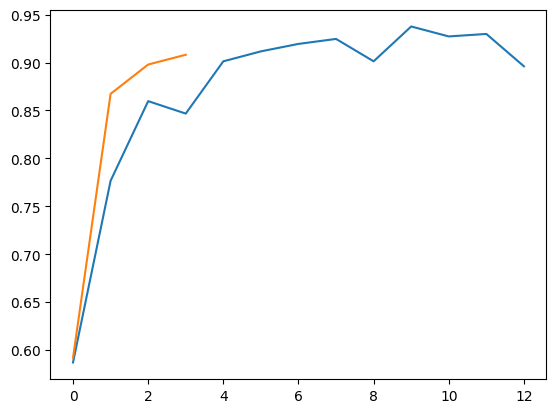

In [67]:
#훈련과 테스트 데이터의 정확도를 그래프로 확인
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

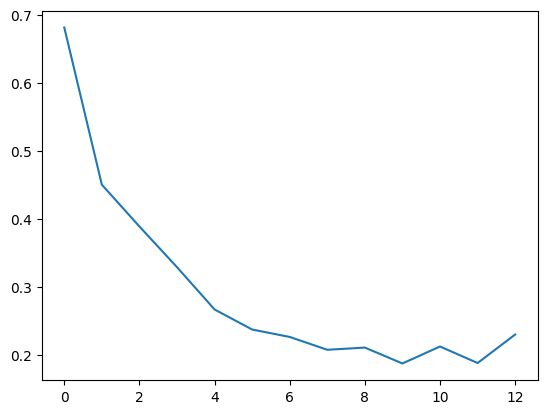

In [68]:
#훈련 데이터의 오차에 대한 그래프 확인
plt.plot(train_loss_hist)
plt.show()

In [69]:
#예측 이미지 출력을 위한 전처리 함수
def im_convert(tensor):
  image = tensor.clone().detach().numpy()
  image = image.transpose(1, 2, 0)
  image = image * (np.array((0.5, 0.5, 0.5)) + np.array((0.5, 0.5, 0.5)))
  image = image.clip(0, 1)
  return image

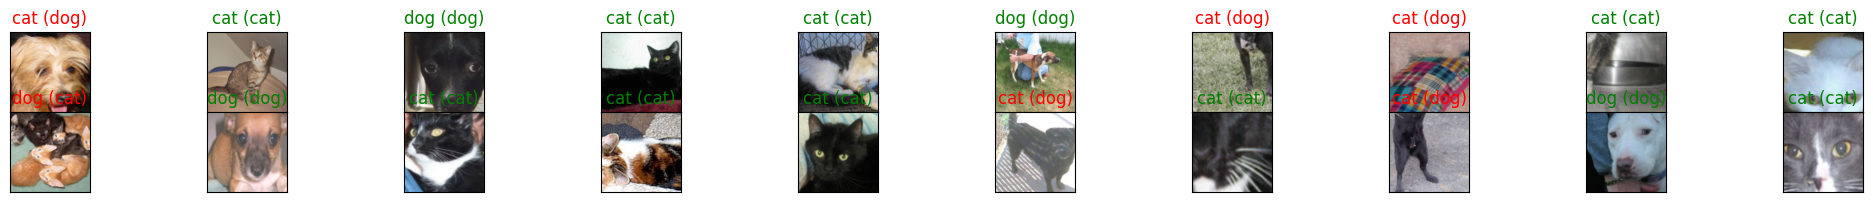

In [70]:
#개/고양이 예측 출력
classes = {0: 'cat', 1: 'dog'}

dataiter = iter(test_loader)
images, labels = next(dataiter)
output = model(images)
_, preds = torch.max(output, 1)

fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
  ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
  plt.imshow(im_convert(images[idx]))
  ax.set_title("{} ({})".format(str(classes[preds[idx].item()]), str(classes[labels[idx].item()])),
               color=("green" if preds[idx]==labels[idx] else "red"))
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)
plt.show()

# 특성 맵 시각화

In [37]:
pip install pillow

In [38]:
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.transforms import ToTensor
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [41]:
#설명 가능한 네트워크 생성
class XAI(torch.nn.Module):
  def __init__(self, num_classes=2):
    super(XAI, self).__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3, 64, kernel_size=3, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Conv2d(64, 64, kernel_size=3, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.classifier= nn.Sequential(
        nn.Linear(512, 512, bias=False),
        nn.Dropout(0.5),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(512,num_classes)
    )
  def forward(self, x):
    x = self.features(x)
    x = x.view(-1, 512)
    x = self.classifier(x)
    return F.log_softmax(x)

In [42]:
#모델 객체화
model = XAI()
model.to(device)
model.eval()

XAI(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True)
    (15): MaxP

In [43]:
#특성 맵을 확인하기 위한 클래스 정의
class LayersActivations:
  features =[]
  def __init__(self, model, layer_num):
    self.hook = model[layer_num].register_forward_hook(self.hook_fn)

  def hook_fn(self, module, input, output):
    self.features = output.detach().numpy()

  def remove(self):
    self.hook.remove()

torch.Size([1, 3, 100, 100])


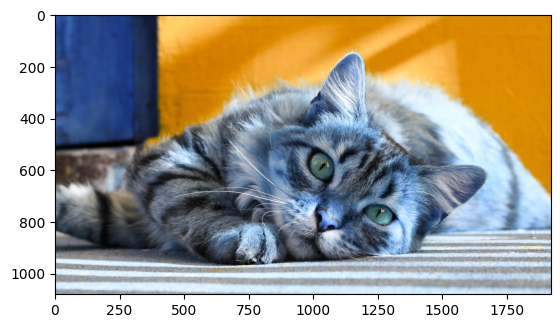

In [45]:
#이미지 호출
img = cv2.imread("/content/drive/MyDrive/Euron/cat.jpg")
plt.imshow(img)
img = cv2.resize(img, (100, 100), interpolation=cv2.INTER_LINEAR)
img = ToTensor()(img).unsqueeze(0)
print(img.shape)

In [46]:
#Conv2d특성 맵 확인
result = LayersActivations(model.features, 0)

model(img)
activations = result.features

/tmp/ipykernel_9765/295606207.py:71: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


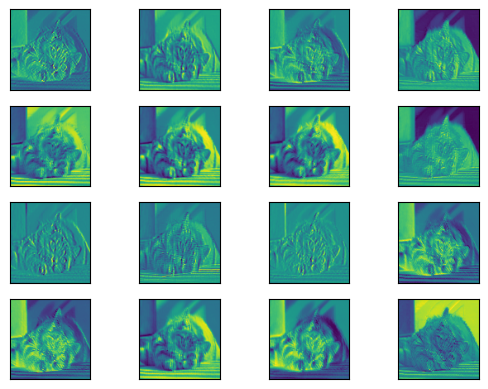

<Figure size 1200x800 with 0 Axes>

In [47]:
#특성 맵 확인
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()

In [49]:
#20번째 계층에 대한 특성 맵
result = LayersActivations(model.features, 20)
model(img)
activations = result.features

/tmp/ipykernel_9765/295606207.py:71: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


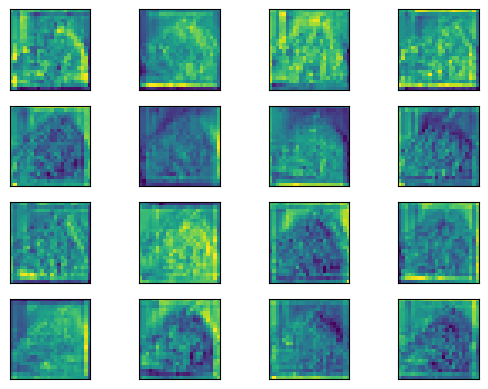

<Figure size 1200x800 with 0 Axes>

In [50]:
#특성 맵 확인
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()

In [51]:
#40번째 계층에 대한 특성 맵
result = LayersActivations(model.features, 40)
model(img)
activations = result.features

/tmp/ipykernel_9765/295606207.py:71: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


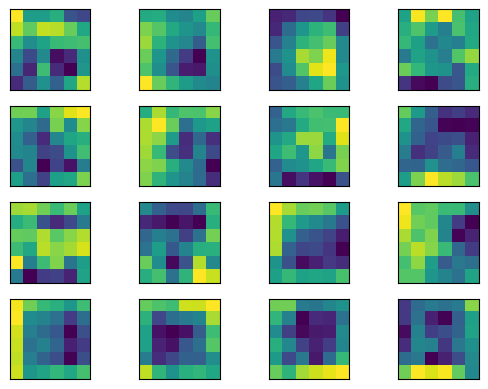

<Figure size 1200x800 with 0 Axes>

In [52]:
#특성 맵 확인
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
  for column in range(4):
    axis = axes[row][column]
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    axis.imshow(activations[0][row*10+column])
plt.show()